# Two-Filter and Fixed-Lag Smoothers

This notebook demonstrates two additional particle smoothing algorithms:

- **Two-Filter Smoother**: Combines a forward particle filter $p(h_t \mid y_{1:t})$ with a
  backward information filter $p(y_{t+1:T} \mid h_t)$ to produce smoothed estimates.
- **Fixed-Lag Smoother**: Computes $p(h_t \mid y_{1:t+L})$ with a fixed lag $L$, providing
  **online** smoothing with a bounded delay.

We compare these methods against FFBSm and analyze the effect of the lag parameter $L$.

**References:**
- Briers, Doucet & Maskell (2010). *Smoothing algorithms for state-space models.*
- Kitagawa (1996). *Monte Carlo filter and smoother for non-Gaussian nonlinear state space models.*
- Doucet & Johansen (2009). *A tutorial on particle filtering and smoothing: Fifteen years later.*


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass, field
import time
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

# Import particlefilterbox smoothers
from particlefilterbox.smoothers import FFBSm, TwoFilterSmoother, FixedLagSmoother


In [2]:
# Load simulated SV data
data_path = Path('..') / 'data' / 'simulated_sv.csv'
df_full = pd.read_csv(data_path)

# Use first 100 observations for manageable runtime
T_USE = 100
df = df_full.iloc[:T_USE].reset_index(drop=True)
y_obs = df['y_obs'].values
h_true = df['h_true'].values
T = len(y_obs)
print(f"Using T = {T} observations (from {len(df_full)} total)")


Using T = 100 observations (from 1000 total)


## Mathematical Background

### Two-Filter Smoother

The smoothing distribution can be decomposed as:

$$p(h_t \mid y_{1:T}) \propto p(h_t \mid y_{1:t}) \cdot p(y_{t+1:T} \mid h_t)$$

- **Forward filter**: standard particle filter gives $p(h_t \mid y_{1:t})$
- **Backward information filter**: propagates future information backward to compute $p(y_{t+1:T} \mid h_t)$

The two-filter smoother combines both by multiplying forward weights with backward likelihood contributions.

### Fixed-Lag Smoother

Instead of using all $T$ observations, the fixed-lag smoother estimates:

$$p(h_t \mid y_{1:\min(t+L, T)})$$

where $L$ is the lag. Key properties:
- $L = 0$: equivalent to filtering
- $L = T$: approaches full (fixed-interval) smoothing
- $L$ intermediate: trade-off between latency and accuracy

The fixed-lag smoother traces particle ancestors $L$ steps back and applies current weights,
making it suitable for **online/streaming** applications.


In [3]:
# SV model parameters
mu, phi, sigma = -1.0, 0.97, 0.15

@dataclass
class SVModelForSmoothing:
    """SV model with methods required by all smoothers."""
    mu: float = -1.0
    phi: float = 0.97
    sigma: float = 0.15

    def log_transition_density(self, x_new: np.ndarray, x_old: np.ndarray, t: int) -> np.ndarray:
        if x_new.ndim == 1:
            x_new = x_new.reshape(1, -1)
        if x_old.ndim == 1:
            x_old = x_old.reshape(1, -1)
        mean = self.mu + self.phi * (x_old[:, 0] - self.mu)
        return -0.5 * np.log(2 * np.pi * self.sigma**2) - 0.5 * ((x_new[:, 0] - mean) / self.sigma)**2

    def log_observation_density(self, y: np.ndarray, x: np.ndarray, t: int) -> np.ndarray:
        if x.ndim == 1:
            x = x.reshape(1, -1)
        h = x[:, 0]
        vol = np.exp(h / 2.0)
        y_val = float(y) if np.isscalar(y) else float(y[0]) if hasattr(y, '__len__') else float(y)
        return -0.5 * np.log(2.0 * np.pi) - np.log(vol) - 0.5 * (y_val / vol)**2

model = SVModelForSmoothing(mu=mu, phi=phi, sigma=sigma)

# Storage for filter results
@dataclass
class FilterResultsForSmoother:
    particles_history: list = field(default_factory=list)
    weights_history: list = field(default_factory=list)
    filtered_mean: np.ndarray = field(default_factory=lambda: np.array([]))
    filtered_cov: np.ndarray = field(default_factory=lambda: np.array([]))
    observations: np.ndarray = field(default_factory=lambda: np.array([]))
    ancestor_indices: list = field(default_factory=list)

# Run Bootstrap PF
N = 2000
rng = np.random.default_rng(42)
var_stat = sigma**2 / (1.0 - phi**2)
particles = rng.normal(mu, np.sqrt(var_stat), size=(N, 1))

particles_history = []
weights_history = []
ancestor_indices_history = []
filtered_mean = np.zeros((T, 1))
filtered_cov = np.zeros((T, 1, 1))

print(f"Running Bootstrap PF with N={N} particles, T={T} steps...")
t0 = time.perf_counter()

for t in range(T):
    if t > 0:
        eta = rng.standard_normal(size=(N, 1))
        particles = mu + phi * (particles - mu) + sigma * eta

    h = particles[:, 0]
    vol = np.exp(h / 2.0)
    log_w = -0.5 * np.log(2.0 * np.pi) - np.log(vol) - 0.5 * (y_obs[t] / vol)**2
    max_lw = np.max(log_w)
    w = np.exp(log_w - max_lw)
    w_normalized = w / np.sum(w)

    particles_history.append(particles.copy())
    weights_history.append(w_normalized.copy())

    filtered_mean[t, 0] = np.sum(w_normalized * particles[:, 0])
    diff = particles[:, 0] - filtered_mean[t, 0]
    filtered_cov[t, 0, 0] = np.sum(w_normalized * diff**2)

    ess = 1.0 / np.sum(w_normalized**2)
    if ess < N / 2:
        cumsum = np.cumsum(w_normalized)
        u = (rng.random() + np.arange(N)) / N
        indices = np.searchsorted(cumsum, u)
        indices = np.clip(indices, 0, N - 1)
        ancestor_indices_history.append(indices.copy())
        particles = particles[indices].copy()
    else:
        ancestor_indices_history.append(np.arange(N))

elapsed_filter = time.perf_counter() - t0

filter_results = FilterResultsForSmoother(
    particles_history=particles_history,
    weights_history=weights_history,
    filtered_mean=filtered_mean,
    filtered_cov=filtered_cov,
    observations=y_obs.reshape(-1, 1),
    ancestor_indices=ancestor_indices_history,
)

rmse_filter = np.sqrt(np.mean((filtered_mean[:, 0] - h_true)**2))
print(f"Filter completed in {elapsed_filter:.2f}s, RMSE = {rmse_filter:.4f}")


Running Bootstrap PF with N=2000 particles, T=100 steps...
Filter completed in 0.01s, RMSE = 0.5272


In [4]:
# Run Two-Filter Smoother
print("Running Two-Filter Smoother...")
tfs = TwoFilterSmoother(seed=42)
t0 = time.perf_counter()
results_tfs = tfs.smooth(filter_results, model)
elapsed_tfs = time.perf_counter() - t0
rmse_tfs = np.sqrt(np.mean((results_tfs.smoothed_mean[:, 0] - h_true)**2))
print(f"Two-Filter completed in {elapsed_tfs:.2f}s, RMSE = {rmse_tfs:.4f}")

# Also run FFBSm for comparison
print("\nRunning FFBSm for comparison...")
ffbsm = FFBSm()
t0 = time.perf_counter()
results_ffbsm = ffbsm.smooth(filter_results, model)
elapsed_ffbsm = time.perf_counter() - t0
rmse_ffbsm = np.sqrt(np.mean((results_ffbsm.smoothed_mean[:, 0] - h_true)**2))
print(f"FFBSm completed in {elapsed_ffbsm:.2f}s, RMSE = {rmse_ffbsm:.4f}")


Running Two-Filter Smoother...


Two-Filter completed in 12.07s, RMSE = 0.5413

Running FFBSm for comparison...


FFBSm completed in 11.96s, RMSE = 0.6079


In [5]:
# Run Fixed-Lag Smoother with multiple lag values
lag_values = [5, 10, 20, 50]
results_fl = {}
elapsed_fl = {}

for L in lag_values:
    print(f"Running Fixed-Lag Smoother with L={L}...")
    fls = FixedLagSmoother(lag=L)
    t0 = time.perf_counter()
    results_fl[L] = fls.smooth(filter_results, model)
    elapsed_fl[L] = time.perf_counter() - t0
    rmse = np.sqrt(np.mean((results_fl[L].smoothed_mean[:, 0] - h_true)**2))
    print(f"  L={L}: RMSE = {rmse:.4f}, Time = {elapsed_fl[L]:.2f}s")


Running Fixed-Lag Smoother with L=5...
  L=5: RMSE = 0.5604, Time = 0.03s
Running Fixed-Lag Smoother with L=10...
  L=10: RMSE = 0.5904, Time = 0.03s
Running Fixed-Lag Smoother with L=20...
  L=20: RMSE = 0.6543, Time = 0.04s
Running Fixed-Lag Smoother with L=50...
  L=50: RMSE = 0.6458, Time = 0.05s


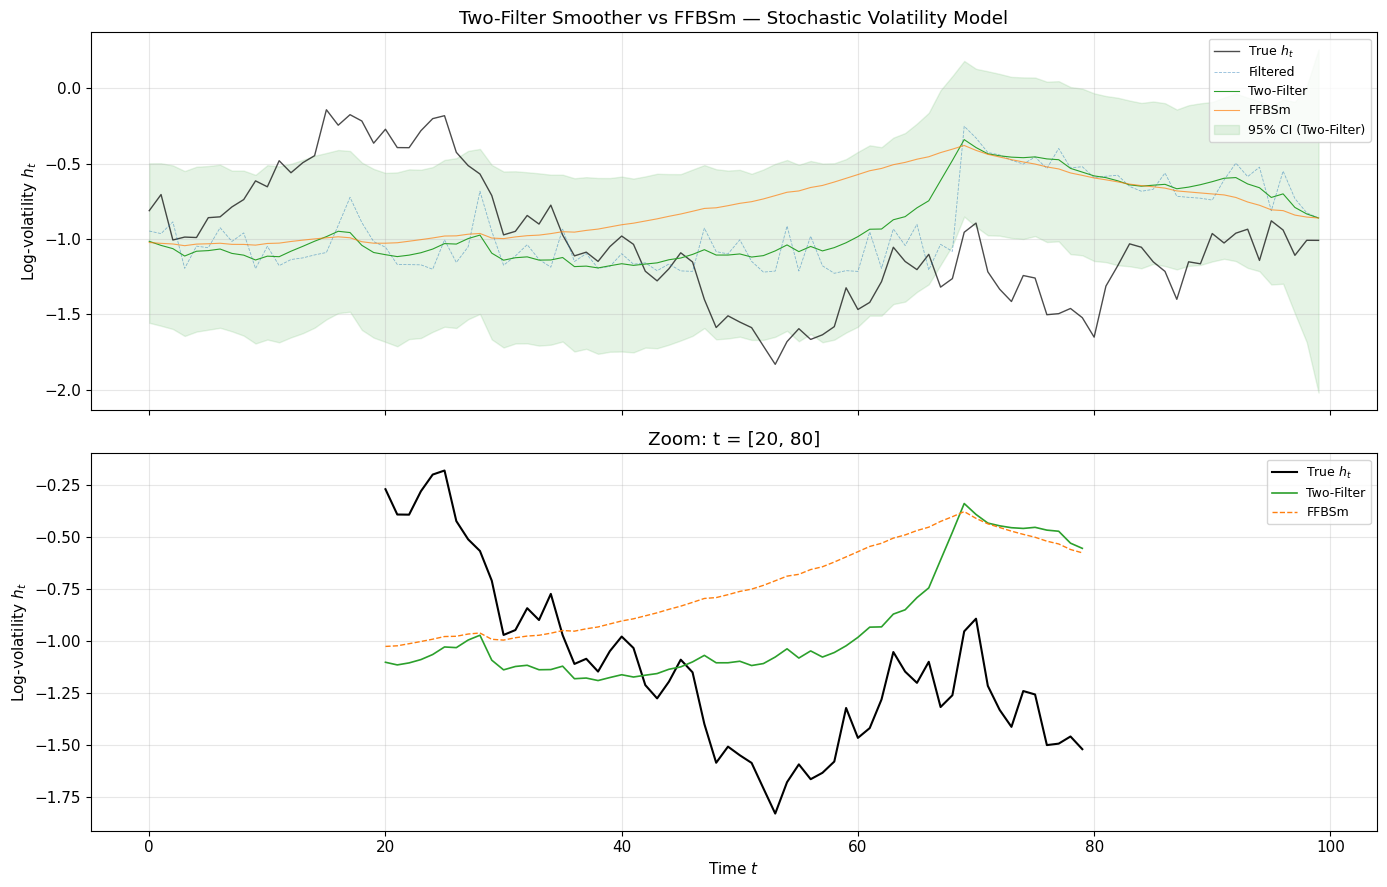

In [6]:
# Plot: h_true vs two-filter vs FFBSm with confidence intervals
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
t_axis = np.arange(T)

ax = axes[0]
ax.plot(t_axis, h_true, 'k-', lw=1.0, alpha=0.7, label='True $h_t$')
ax.plot(t_axis, filtered_mean[:, 0], 'C0--', lw=0.6, alpha=0.5, label='Filtered')
ax.plot(t_axis, results_tfs.smoothed_mean[:, 0], 'C2-', lw=0.8, label='Two-Filter')
ax.plot(t_axis, results_ffbsm.smoothed_mean[:, 0], 'C1-', lw=0.8, alpha=0.7, label='FFBSm')

if 0.025 in results_tfs.smoothed_quantiles:
    q025 = results_tfs.smoothed_quantiles[0.025][:, 0]
    q975 = results_tfs.smoothed_quantiles[0.975][:, 0]
    ax.fill_between(t_axis, q025, q975, alpha=0.12, color='C2', label='95% CI (Two-Filter)')

ax.set_ylabel('Log-volatility $h_t$')
ax.set_title('Two-Filter Smoother vs FFBSm — Stochastic Volatility Model')
ax.legend(loc='upper right', fontsize=9)

# Zoom
zoom_start, zoom_end = 20, 80
ax = axes[1]
idx = slice(zoom_start, zoom_end)
ax.plot(t_axis[idx], h_true[idx], 'k-', lw=1.5, label='True $h_t$')
ax.plot(t_axis[idx], results_tfs.smoothed_mean[idx, 0], 'C2-', lw=1.2, label='Two-Filter')
ax.plot(t_axis[idx], results_ffbsm.smoothed_mean[idx, 0], 'C1--', lw=1.0, label='FFBSm')
ax.set_xlabel('Time $t$')
ax.set_ylabel('Log-volatility $h_t$')
ax.set_title(f'Zoom: t = [{zoom_start}, {zoom_end}]')
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()


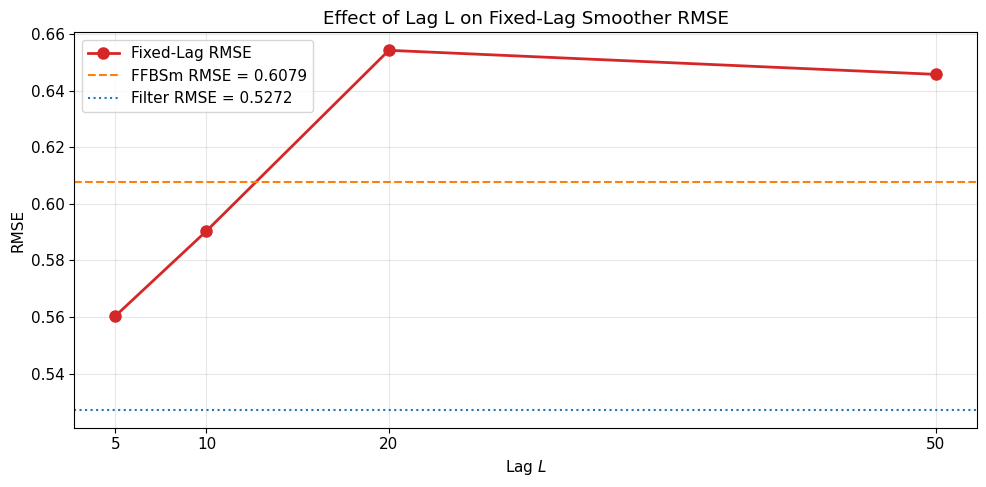

Filter RMSE:         0.5272
Fixed-Lag L=  5:     0.5604
Fixed-Lag L= 10:     0.5904
Fixed-Lag L= 20:     0.6543
Fixed-Lag L= 50:     0.6458
FFBSm (full smooth): 0.6079


In [7]:
# Plot: Effect of lag L on Fixed-Lag RMSE
rmse_values = []
for L in lag_values:
    rmse = np.sqrt(np.mean((results_fl[L].smoothed_mean[:, 0] - h_true)**2))
    rmse_values.append(rmse)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(lag_values, rmse_values, 'o-', color='C3', lw=2, ms=8, label='Fixed-Lag RMSE')
ax.axhline(rmse_ffbsm, color='C1', ls='--', lw=1.5, label=f'FFBSm RMSE = {rmse_ffbsm:.4f}')
ax.axhline(rmse_filter, color='C0', ls=':', lw=1.5, label=f'Filter RMSE = {rmse_filter:.4f}')

ax.set_xlabel('Lag $L$')
ax.set_ylabel('RMSE')
ax.set_title('Effect of Lag L on Fixed-Lag Smoother RMSE')
ax.legend()
ax.set_xticks(lag_values)
plt.tight_layout()
plt.show()

print(f"Filter RMSE:         {rmse_filter:.4f}")
for L, rmse in zip(lag_values, rmse_values):
    print(f"Fixed-Lag L={L:>3d}:     {rmse:.4f}")
print(f"FFBSm (full smooth): {rmse_ffbsm:.4f}")


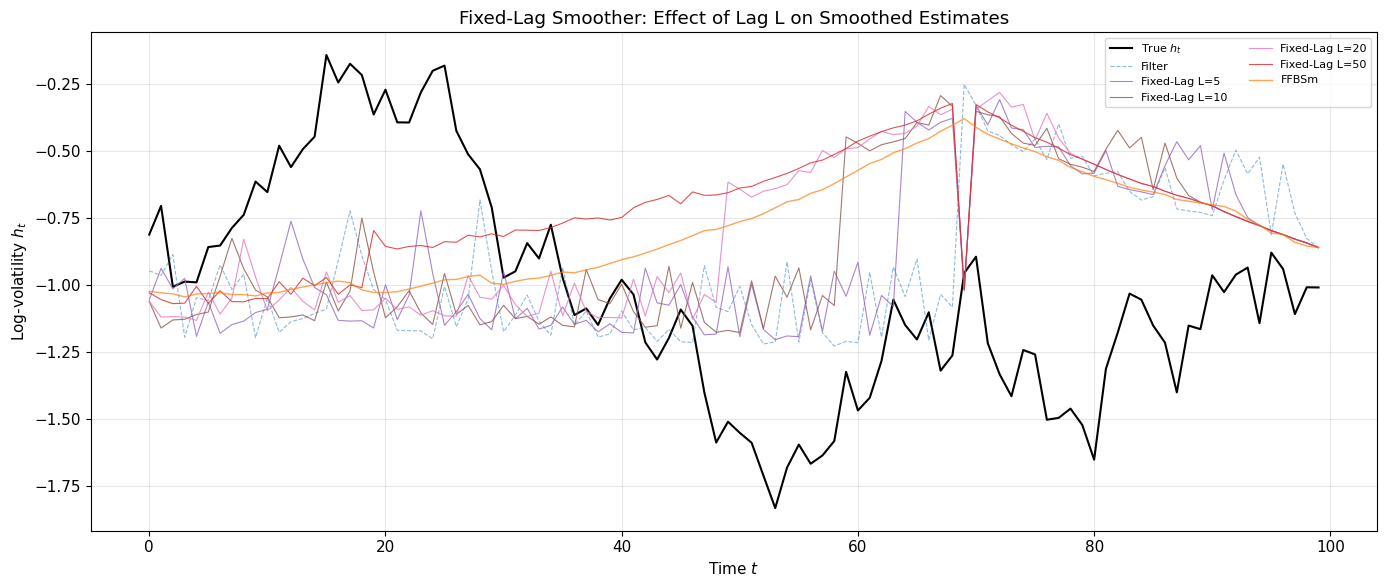

In [8]:
# Plot: Fixed-lag smoothed estimates for different L values
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(t_axis, h_true, 'k-', lw=1.5, label='True $h_t$')
ax.plot(t_axis, filtered_mean[:, 0], 'C0--', lw=0.8, alpha=0.5, label='Filter')

colors_fl = ['C4', 'C5', 'C6', 'C3']
for L, color in zip(lag_values, colors_fl):
    ax.plot(t_axis, results_fl[L].smoothed_mean[:, 0], color=color, lw=0.8,
            alpha=0.8, label=f'Fixed-Lag L={L}')

ax.plot(t_axis, results_ffbsm.smoothed_mean[:, 0], 'C1-', lw=1.0, alpha=0.7, label='FFBSm')

ax.set_xlabel('Time $t$')
ax.set_ylabel('Log-volatility $h_t$')
ax.set_title('Fixed-Lag Smoother: Effect of Lag L on Smoothed Estimates')
ax.legend(loc='upper right', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


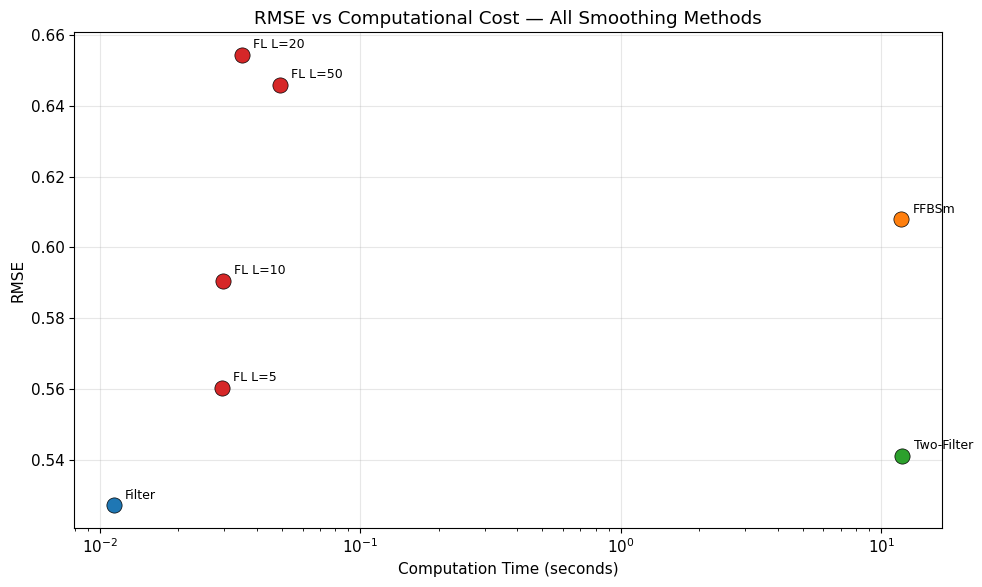

In [9]:
# Plot: RMSE vs computational cost for each method
methods = ['Filter']
rmses = [rmse_filter]
times = [elapsed_filter]
colors = ['C0']

for L in lag_values:
    methods.append(f'FL L={L}')
    rmses.append(np.sqrt(np.mean((results_fl[L].smoothed_mean[:, 0] - h_true)**2)))
    times.append(elapsed_fl[L])
    colors.append('C3')

methods.append('Two-Filter')
rmses.append(rmse_tfs)
times.append(elapsed_tfs)
colors.append('C2')

methods.append('FFBSm')
rmses.append(rmse_ffbsm)
times.append(elapsed_ffbsm)
colors.append('C1')

fig, ax = plt.subplots(figsize=(10, 6))
for m, r, t_val, c in zip(methods, rmses, times, colors):
    ax.scatter(t_val, r, s=120, c=c, zorder=5, edgecolors='k', linewidth=0.5)
    ax.annotate(m, (t_val, r), textcoords="offset points", xytext=(8, 5), fontsize=9)

ax.set_xlabel('Computation Time (seconds)')
ax.set_ylabel('RMSE')
ax.set_title('RMSE vs Computational Cost — All Smoothing Methods')
ax.set_xscale('log')
plt.tight_layout()
plt.show()


In [10]:
# Final comparison table: all smoothers (FFBSm, Two-Filter, Fixed-Lag L=10)
rows = []
rows.append({
    'Method': 'Filter',
    'RMSE': rmse_filter,
    'MAE': np.mean(np.abs(filtered_mean[:, 0] - h_true)),
    'Mean Var': np.mean(filtered_cov[:, 0, 0]),
    'Time (s)': elapsed_filter,
    'Online': 'Yes',
})
rows.append({
    'Method': 'FFBSm',
    'RMSE': rmse_ffbsm,
    'MAE': np.mean(np.abs(results_ffbsm.smoothed_mean[:, 0] - h_true)),
    'Mean Var': np.mean(results_ffbsm.smoothed_cov[:, 0, 0]),
    'Time (s)': elapsed_ffbsm,
    'Online': 'No',
})
rows.append({
    'Method': 'Two-Filter',
    'RMSE': rmse_tfs,
    'MAE': np.mean(np.abs(results_tfs.smoothed_mean[:, 0] - h_true)),
    'Mean Var': np.mean(results_tfs.smoothed_cov[:, 0, 0]),
    'Time (s)': elapsed_tfs,
    'Online': 'No',
})
rows.append({
    'Method': 'Fixed-Lag L=10',
    'RMSE': np.sqrt(np.mean((results_fl[10].smoothed_mean[:, 0] - h_true)**2)),
    'MAE': np.mean(np.abs(results_fl[10].smoothed_mean[:, 0] - h_true)),
    'Mean Var': np.mean(results_fl[10].smoothed_cov[:, 0, 0]),
    'Time (s)': elapsed_fl[10],
    'Online': 'Yes',
})

table = pd.DataFrame(rows)
print("=== Comprehensive Smoother Comparison (SV Model, T={}, N={}) ===".format(T, N))
print(table.to_string(index=False, float_format='%.4f'))

# Variance comparison
mean_var_filter = np.mean(filtered_cov[:, 0, 0])
mean_var_ffbsm = np.mean(results_ffbsm.smoothed_cov[:, 0, 0])
mean_var_tfs = np.mean(results_tfs.smoothed_cov[:, 0, 0])
print(f"\nVariance reduction vs filter:")
print(f"  FFBSm:      {(1 - mean_var_ffbsm / mean_var_filter)*100:.1f}%")
print(f"  Two-Filter: {(1 - mean_var_tfs / mean_var_filter)*100:.1f}%")

# Fixed-lag convergence analysis
print(f"\nFixed-Lag RMSE convergence:")
for L in lag_values:
    rmse_fl = np.sqrt(np.mean((results_fl[L].smoothed_mean[:, 0] - h_true)**2))
    mean_var_fl = np.mean(results_fl[L].smoothed_cov[:, 0, 0])
    print(f"  L={L:>3d}: RMSE={rmse_fl:.4f}, Mean Var={mean_var_fl:.4f}")
print(f"  FFBSm: RMSE={rmse_ffbsm:.4f}, Mean Var={mean_var_ffbsm:.4f}")
print("As L increases, the fixed-lag smoother uses more future information,")
print("approaching the full (fixed-interval) smoother result.")


=== Comprehensive Smoother Comparison (SV Model, T=100, N=2000) ===
        Method   RMSE    MAE  Mean Var  Time (s) Online
        Filter 0.5272 0.4388    0.3222    0.0113    Yes
         FFBSm 0.6079 0.5254    0.2843   11.9604     No
    Two-Filter 0.5413 0.4700    0.0847   12.0678     No
Fixed-Lag L=10 0.5904 0.5043    0.3301    0.0297    Yes

Variance reduction vs filter:
  FFBSm:      11.7%
  Two-Filter: 73.7%

Fixed-Lag RMSE convergence:
  L=  5: RMSE=0.5604, Mean Var=0.3284
  L= 10: RMSE=0.5904, Mean Var=0.3301
  L= 20: RMSE=0.6543, Mean Var=0.3306
  L= 50: RMSE=0.6458, Mean Var=0.3298
  FFBSm: RMSE=0.6079, Mean Var=0.2843
As L increases, the fixed-lag smoother uses more future information,
approaching the full (fixed-interval) smoother result.


## Conclusions: When to Use Each Smoother

| Smoother | Complexity | Online? | Best For |
|----------|-----------|---------|----------|
| **FFBSm** | $O(T \cdot N^2)$ | No | Gold standard for offline marginal smoothing |
| **FFBSi** | $O(T \cdot N \cdot M)$ | No | Path-dependent functionals, MCMC/Gibbs |
| **Two-Filter** | $O(T \cdot N^2)$ | No | Alternative to FFBSm; may handle multi-modal states better |
| **Fixed-Lag** | $O(T \cdot N \cdot L)$ | **Yes** | Real-time / streaming applications with bounded delay |

### Key takeaways

1. **Two-Filter smoother** combines forward and backward information independently, making it
   conceptually different from FFBSm. It can be more robust when the forward filter degenerates.

2. **Fixed-Lag smoother** is the only **online** method — it can produce smoothed estimates
   with a fixed delay $L$, making it ideal for real-time applications.

3. **Increasing the lag $L$** in the fixed-lag smoother uses more future observations,
   approaching the full smoother as $L \to T$.

4. **Computational cost** varies dramatically: Fixed-Lag is cheapest, FFBSm/Two-Filter are
   most expensive due to $O(N^2)$ terms. Choose based on the accuracy-latency-cost trade-off.
